# 03 - Entrenamiento del modelo final

Este notebook deja de ser un registro largo de todo el laboratorio y se enfoca en el sistema que se decide presentar.

El modelo final oficial es un soft voting de tres ramas entrenadas a 100 epocas:

```text
0.25  * separable_headsep_e100_seed42
+ 0.375 * globalmel_sep_temporal_e100_seed42
+ 0.375 * sep_temporal_f1024_e100_seed42
```

Private LB: `0.67126`.


## 1. Configuracion y artefactos

Cada rama produce un CSV con 80 probabilidades por audio. En entrenamiento se usan salidas `sigmoid`, porque el problema es multietiqueta: un audio puede tener mas de una clase verdadera.


In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'data' / 'sample_submission.csv').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('No pude encontrar la raiz del repo')
    ROOT = ROOT.parent

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

pd.set_option('display.max_colwidth', 120)

RESULTS = ROOT / '03_entrenamiento' / 'results'
FIGURES = RESULTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

component_rows = [
    {
        'component': 'separable_headsep_e100_seed42',
        'weight': 0.25,
        'input': 'log-mel 128 x 512',
        'normalization': 'por clip',
        'architecture': 'CNN separable-residual + cabeza densa',
        'temporal_model': 'no; pooling global',
        'epochs': 100,
        'seed': 42,
        'artifact': 'investigation/submissions/parallel100_20260702_separable_headsep_e100_seed42/small_logmel_cnn.csv',
        'role': 'patrones locales tiempo-frecuencia',
    },
    {
        'component': 'globalmel_sep_temporal_e100_seed42',
        'weight': 0.375,
        'input': 'log-mel 128 x 512',
        'normalization': 'global por banda mel',
        'architecture': 'CNN separable-residual + BiGRU',
        'temporal_model': 'si; BiGRU bidireccional',
        'epochs': 100,
        'seed': 42,
        'artifact': 'investigation/submissions/parallel100_20260702_globalmel_sep_temporal_e100_seed42/small_logmel_cnn.csv',
        'role': 'normalizacion estable y evolucion temporal',
    },
    {
        'component': 'sep_temporal_f1024_e100_seed42',
        'weight': 0.375,
        'input': 'log-mel 128 x 1024',
        'normalization': 'por clip',
        'architecture': 'CNN separable-residual + BiGRU',
        'temporal_model': 'si; BiGRU bidireccional',
        'epochs': 100,
        'seed': 42,
        'artifact': 'investigation/submissions/parallel100_20260702_sep_temporal_f1024_e100_seed42/small_logmel_cnn.csv',
        'role': 'contexto temporal largo',
    },
]
components = pd.DataFrame(component_rows)
components['exists'] = components['artifact'].map(lambda p: (ROOT / p).exists())
components.to_csv(RESULTS / 'final_training_components.csv', index=False)
display(components)


,component,weight,input,normalization,architecture,temporal_model,epochs,seed,artifact,role,exists
0,separable_headsep_e100_seed42,0.250,log-mel 128 x 512,por clip,CNN separable-residual + cabeza densa,no; pooling global,100,42,investigation/submissions/parallel100_20260702_separable_headsep_e100_seed42/small_logmel_cnn.csv,patrones locales tiempo-frecuencia,True
1,globalmel_sep_temporal_e100_seed42,0.375,log-mel 128 x 512,global por banda mel,CNN separable-residual + BiGRU,si; BiGRU bidireccional,100,42,investigation/submissions/parallel100_20260702_globalmel_sep_temporal_e100_seed42/small_logmel_cnn.csv,normalizacion estable y evolucion temporal,True
2,sep_temporal_f1024_e100_seed42,0.375,log-mel 128 x 1024,por clip,CNN separable-residual + BiGRU,si; BiGRU bidireccional,100,42,investigation/submissions/parallel100_20260702_sep_temporal_f1024_e100_seed42/small_logmel_cnn.csv,contexto temporal largo,True


## 2. Que aprende cada rama

Las tres ramas comparten la representacion log-mel, pero no son redundantes.

- `separable_headsep`: mira el espectrograma como imagen y aprende patrones locales.
- `globalmel_sep_temporal`: conserva el eje temporal y usa normalizacion global por banda mel.
- `sep_temporal_f1024`: conserva el eje temporal y mira una ventana mas larga.


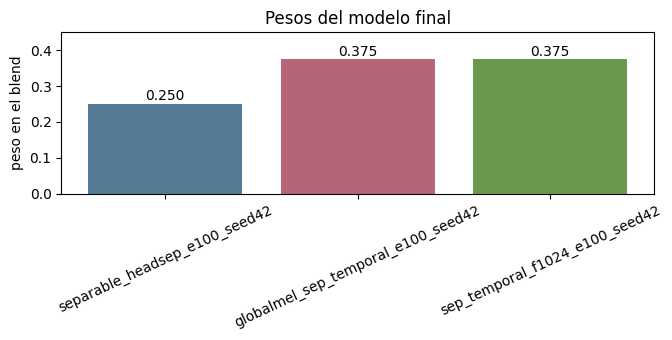

In [2]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(components['component'], components['weight'], color=['#557a95', '#b56576', '#6a994e'])
ax.set_ylabel('peso en el blend')
ax.set_title('Pesos del modelo final')
ax.set_ylim(0, 0.45)
ax.tick_params(axis='x', rotation=25)
for index, row in components.iterrows():
    ax.text(index, row['weight'] + 0.01, f"{row['weight']:.3f}", ha='center')
fig.tight_layout()
fig.savefig(FIGURES / 'final_component_weights.png', dpi=160)
plt.show()


## 3. Entrenar a 100 epocas

El sistema defendible anterior usaba la misma idea de tres ramas, pero con menos entrenamiento. La ronda `parallel100_20260702` muestra que las tres ramas todavia mejoraban al entrenarse a 100 epocas.


,stage,description,private_lb,delta_vs_previous
0,3-way original,"tres ramas previas, pesos iguales",0.66649,NaN
1,3-way e100 equal,"mismas tres ramas a 100 epocas, pesos iguales",0.67055,0.00406
2,3-way e100 weighted,"mismas tres ramas a 100 epocas, pesos 0.25/0.375/0.375",0.67126,0.00071


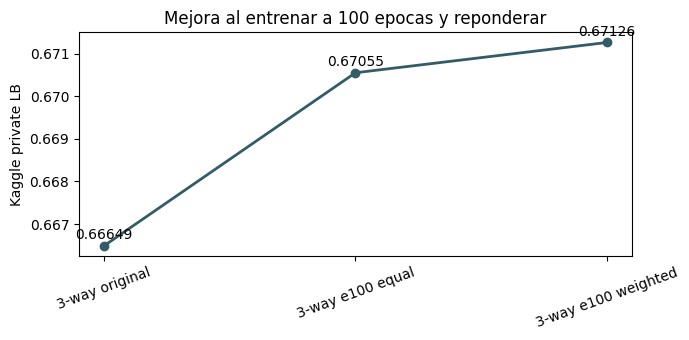

In [3]:
training_progress = pd.DataFrame([
    {'stage': '3-way original', 'description': 'tres ramas previas, pesos iguales', 'private_lb': 0.66649},
    {'stage': '3-way e100 equal', 'description': 'mismas tres ramas a 100 epocas, pesos iguales', 'private_lb': 0.67055},
    {'stage': '3-way e100 weighted', 'description': 'mismas tres ramas a 100 epocas, pesos 0.25/0.375/0.375', 'private_lb': 0.67126},
])
training_progress['delta_vs_previous'] = training_progress['private_lb'].diff()
training_progress.to_csv(RESULTS / 'e100_training_progress.csv', index=False)
display(training_progress)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(training_progress['stage'], training_progress['private_lb'], marker='o', linewidth=2, color='#335c67')
ax.set_ylabel('Kaggle private LB')
ax.set_title('Mejora al entrenar a 100 epocas y reponderar')
ax.tick_params(axis='x', rotation=20)
for idx, value in enumerate(training_progress['private_lb']):
    ax.text(idx, value + 0.00015, f'{value:.5f}', ha='center')
fig.tight_layout()
fig.savefig(FIGURES / 'e100_training_progress.png', dpi=160)
plt.show()


## 4. Regularizacion del modelo final

La regularizacion no esta concentrada en una sola tecnica. En la corrida final se combinan dropout, BatchNorm, augmentation sobre espectrogramas y, en las ramas `AdamW`, decaimiento de pesos.

Hay dos aclaraciones importantes para defensa:

- `block_dropout`, `early_stopping`, time reverse y contraste aleatorio existen como opciones del trainer, pero no se usaron en la corrida final.
- `separable_headsep` usa `Adam`; por como esta implementado `build_optimizer`, esa rama no recibe `weight_decay` efectivo aunque el parser tenga default `1e-4`. Las ramas temporales usan `AdamW`, y ahi si aplica `weight_decay=1e-4`.


In [4]:
metadata_paths = {
    'separable_headsep_e100_seed42': ROOT / 'investigation/experiments/parallel100_20260702_separable_headsep_e100_seed42/small_logmel_cnn_metadata.json',
    'globalmel_sep_temporal_e100_seed42': ROOT / 'investigation/experiments/parallel100_20260702_globalmel_sep_temporal_e100_seed42/small_logmel_cnn_metadata.json',
    'sep_temporal_f1024_e100_seed42': ROOT / 'investigation/experiments/parallel100_20260702_sep_temporal_f1024_e100_seed42/small_logmel_cnn_metadata.json',
}

regularization_rows = []
for component, path in metadata_paths.items():
    meta = json.loads(path.read_text(encoding='utf-8'))
    optimizer = meta['optimizer']
    default_weight_decay = 1e-4
    effective_weight_decay = default_weight_decay if optimizer == 'adamw' else 0.0
    regularization_rows.append({
        'component': component,
        'head_dropout': meta['head_dropout'],
        'block_dropout': meta['block_dropout'],
        'batchnorm': 'si; bloques CNN' + (' + cabeza densa' if component == 'separable_headsep_e100_seed42' else ''),
        'optimizer': optimizer,
        'effective_weight_decay': effective_weight_decay,
        'specaugment_train': 'time shift + time mask + freq mask',
        'time_reverse_probability': meta['time_reverse_probability'],
        'contrast_strength': meta['contrast_strength'],
        'early_stopping_patience': meta['early_stopping_patience'],
        'full_train': meta['full_train'],
    })

regularization = pd.DataFrame(regularization_rows)
regularization.to_csv(RESULTS / 'final_regularization_summary.csv', index=False)
display(regularization)


,component,head_dropout,block_dropout,batchnorm,optimizer,effective_weight_decay,specaugment_train,time_reverse_probability,contrast_strength,early_stopping_patience,full_train
0,separable_headsep_e100_seed42,0.3,0.0,si; bloques CNN + cabeza densa,adam,0.0000,time shift + time mask + freq mask,0.0,0.0,0,True
1,globalmel_sep_temporal_e100_seed42,0.3,0.0,si; bloques CNN,adamw,0.0001,time shift + time mask + freq mask,0.0,0.0,0,True
2,sep_temporal_f1024_e100_seed42,0.3,0.0,si; bloques CNN,adamw,0.0001,time shift + time mask + freq mask,0.0,0.0,0,True


## 5. Configuracion defendible

La reponderacion final no sale de una grilla fina de decimales. Baja moderadamente `headsep` y sube las dos ramas temporales:

```text
headsep:   0.25
globalmel: 0.375
f1024:     0.375
```


In [5]:
summary = {
    'selected_final': '3-way e100 weighted',
    'private_lb': 0.67126,
    'num_physical_components': 3,
    'weights': dict(zip(components['component'], components['weight'])),
    'all_component_artifacts_exist': bool(components['exists'].all()),
}
(RESULTS / 'final_training_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary


{'selected_final': '3-way e100 weighted',
 'private_lb': 0.67126,
 'num_physical_components': 3,
 'weights': {'separable_headsep_e100_seed42': 0.25,
  'globalmel_sep_temporal_e100_seed42': 0.375,
  'sep_temporal_f1024_e100_seed42': 0.375},
 'all_component_artifacts_exist': True}

## 6. Conclusion

La entrega oficial queda como un blend simple de tres ramas entrenadas a 100 epocas. El punto defendible no es solo el score: cada rama cambia una decision concreta de representacion o modelado temporal.
